# 02 — Feature Engineering
**Healthcare Recommendation System — Milestone 2**

Explores the `patient_features` table built by `feature_engineering.py`.  
Validates feature distributions, checks array columns, and previews
what the models will train on.

**Prerequisites:** Run `make run-features` before opening this notebook.

```bash
pip install clickhouse-connect pandas matplotlib seaborn pyarrow
make explore-features
# or: jupyter notebook notebooks/02_feature_engineering.ipynb
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

import clickhouse_connect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
%matplotlib inline

client = clickhouse_connect.get_client(
    host='localhost', port=8123,
    database='healthcare',
    username='healthcare_user',
    password='ch_secret_2026',
    compress=False,
)

def q(sql):
    return client.query_df(sql)

n = client.query('SELECT count() FROM healthcare.patient_features').result_rows[0][0]
print(f'patient_features rows: {n:,}')
assert n > 0, 'patient_features is empty — run make run-features first'

patient_features rows: 11,679


## 1. Feature table overview

In [2]:
# Schema
schema = q("""
    SELECT name, type
    FROM system.columns
    WHERE database = 'healthcare' AND table = 'patient_features'
    ORDER BY position
""")
print('patient_features schema:')
print(schema.to_string(index=False))

patient_features schema:
                    name           type
              patient_id         String
                     age          Int32
          gender_encoded           Int8
            race_encoded           Int8
          num_conditions          Int32
         num_medications          Int32
          num_encounters          Int32
            has_diabetes          UInt8
        has_hypertension          UInt8
              has_asthma          UInt8
      has_hyperlipidemia          UInt8
    has_coronary_disease          UInt8
        condition_vector Array(Float32)
medication_history_flags   Array(UInt8)
         feature_version         String
              created_at  DateTime64(3)


In [3]:
# Load scalar columns (exclude arrays)
df = q("""
    SELECT
        patient_id,
        age, gender_encoded, race_encoded,
        num_conditions, num_medications, num_encounters,
        has_diabetes, has_hypertension, has_asthma,
        has_hyperlipidemia, has_coronary_disease,
        feature_version
    FROM healthcare.patient_features
    ORDER BY patient_id
""")

print(f'Shape: {df.shape}')
print(f'Feature version(s): {df["feature_version"].unique().tolist()}')
df.head(3)

Shape: (11679, 13)
Feature version(s): ['v1.0']


,patient_id,age,gender_encoded,race_encoded,num_conditions,num_medications,num_encounters,has_diabetes,has_hypertension,has_asthma,has_hyperlipidemia,has_coronary_disease,feature_version
0,00022071-35f9-627e-63e6-98cd3a601185,75,1,0,35,13,214,1,1,0,1,1,v1.0
1,0009ed02-6244-66f9-4ba0-42772db4226f,43,0,2,13,7,65,0,0,0,0,0,v1.0
2,0009fc88-4a4b-b4aa-129d-9fcc72332072,22,0,0,17,9,63,0,0,0,0,0,v1.0


## 2. Demographic features

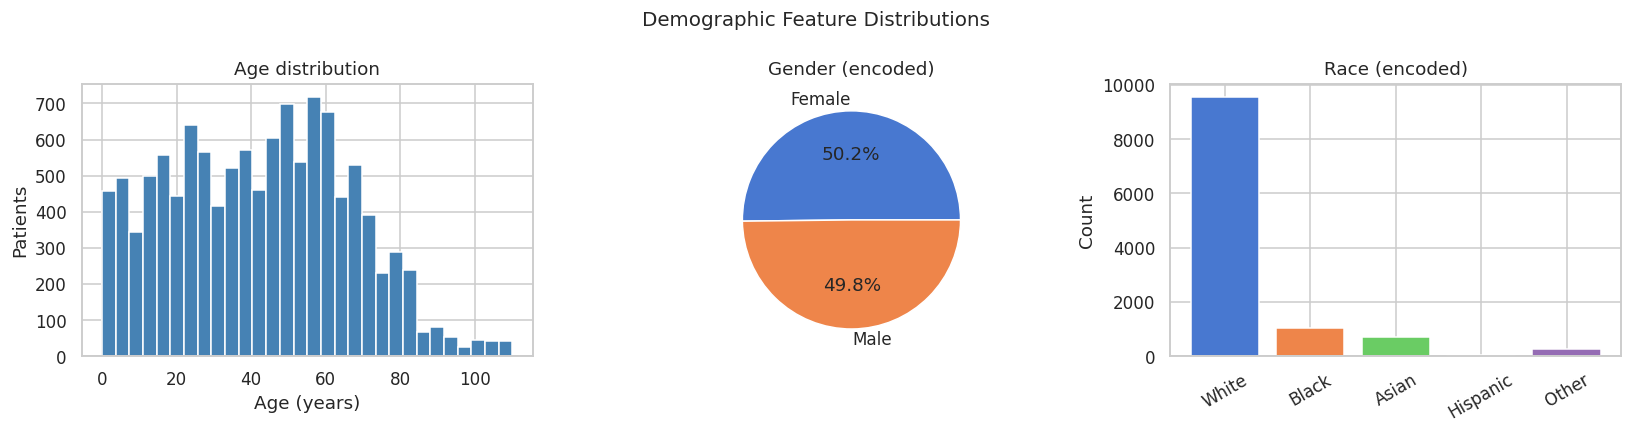

             age
count 11,679.000
mean      42.000
std       23.900
min        0.000
25%       22.000
50%       43.000
75%       60.000
max      110.000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age
axes[0].hist(df['age'].clip(upper=110), bins=30,
             color='steelblue', edgecolor='white')
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Patients')

# Gender
gender_labels = {0: 'Female', 1: 'Male'}
gc = df['gender_encoded'].value_counts().sort_index()
axes[1].pie(gc, labels=[gender_labels[i] for i in gc.index],
            autopct='%1.1f%%', colors=sns.color_palette('muted')[:2])
axes[1].set_title('Gender (encoded)')

# Race
race_labels = {0:'White', 1:'Black', 2:'Asian', 3:'Hispanic', 4:'Native', 5:'Other'}
rc = df['race_encoded'].value_counts().sort_index()
axes[2].bar([race_labels.get(i, str(i)) for i in rc.index],
            rc.values, color=sns.color_palette('muted'))
axes[2].set_title('Race (encoded)')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Demographic Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

print(df[['age']].describe().round(1))

## 3. Count features

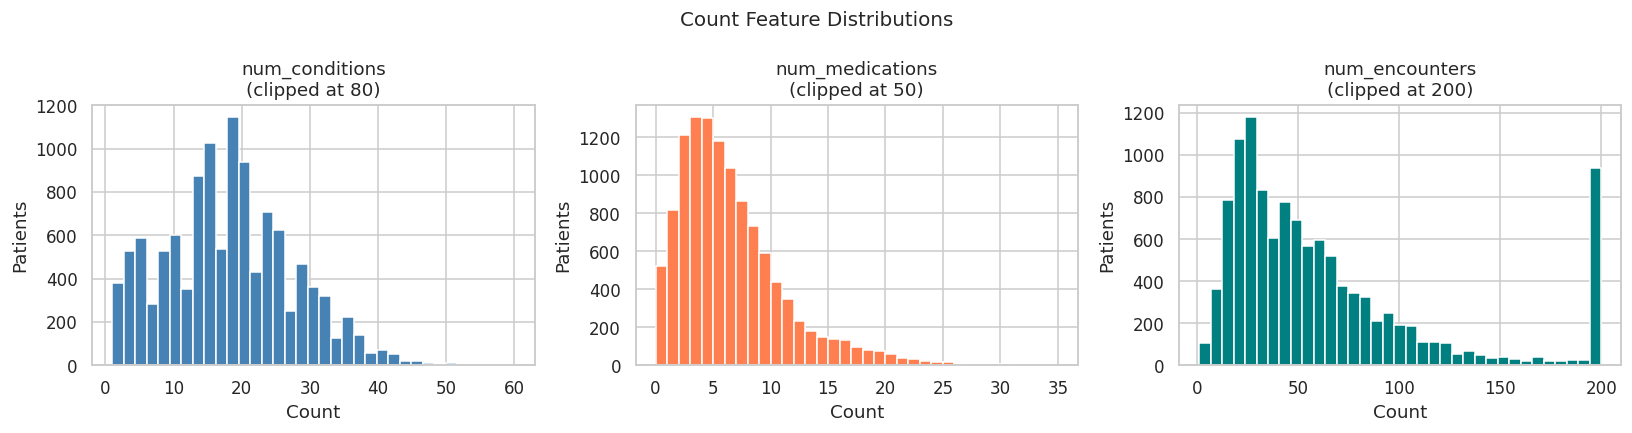

       num_conditions  num_medications  num_encounters
count      11,679.000       11,679.000      11,679.000
mean           18.100            6.100          90.300
std             9.400            4.700         147.500
min             1.000            0.000           1.000
25%            12.000            3.000          26.000
50%            18.000            5.000          47.000
75%            24.000            8.000          79.000
max            60.000           35.000       1,461.000


In [5]:
count_cols = ['num_conditions', 'num_medications', 'num_encounters']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

clips = {'num_conditions': 80, 'num_medications': 50, 'num_encounters': 200}
colors = ['steelblue', 'coral', 'teal']

for ax, col, color in zip(axes, count_cols, colors):
    ax.hist(df[col].clip(upper=clips[col]), bins=35,
            color=color, edgecolor='white')
    ax.set_title(f'{col}\n(clipped at {clips[col]})')
    ax.set_xlabel('Count')
    ax.set_ylabel('Patients')

plt.suptitle('Count Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

print(df[count_cols].describe().round(1))

## 4. Chronic disease flags

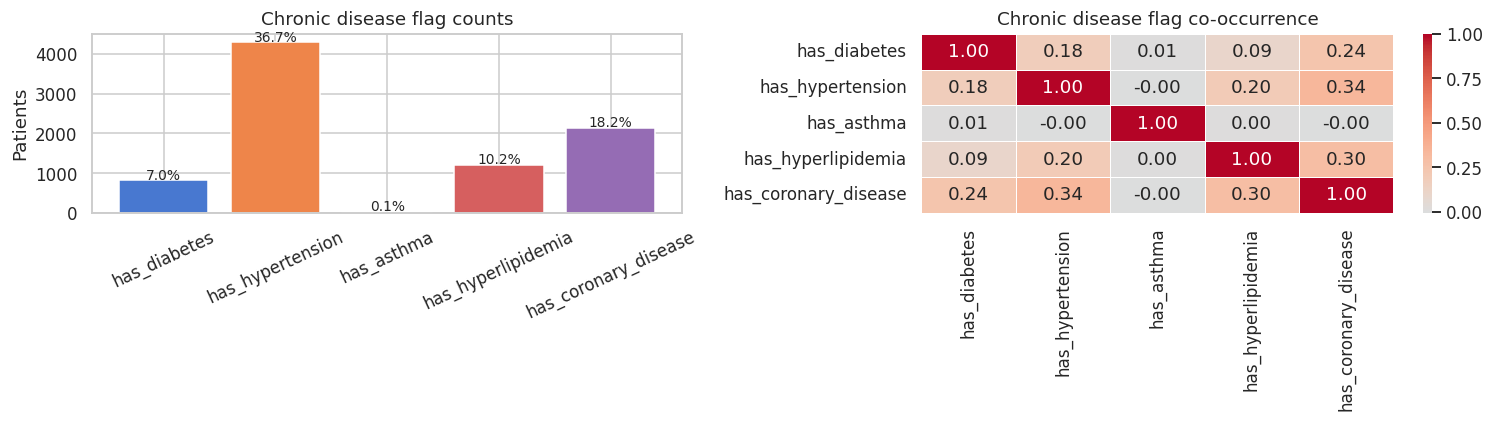


Flag prevalence:
  has_diabetes                 816  (7.0%)
  has_hypertension           4,291  (36.7%)
  has_asthma                    15  (0.1%)
  has_hyperlipidemia         1,197  (10.2%)
  has_coronary_disease       2,130  (18.2%)


In [6]:
flag_cols = ['has_diabetes','has_hypertension','has_asthma',
             'has_hyperlipidemia','has_coronary_disease']

flag_counts = df[flag_cols].sum()
flag_pct    = flag_counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(flag_counts.index, flag_counts.values,
            color=sns.color_palette('muted'))
axes[0].set_title('Chronic disease flag counts')
axes[0].set_ylabel('Patients')
axes[0].tick_params(axis='x', rotation=25)
for i, (val, pct) in enumerate(zip(flag_counts, flag_pct)):
    axes[0].text(i, val + 30, f'{pct:.1f}%', ha='center', fontsize=9)

# Co-occurrence heatmap
corr = df[flag_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], linewidths=0.5)
axes[1].set_title('Chronic disease flag co-occurrence')

plt.tight_layout()
plt.show()

print('\nFlag prevalence:')
for col in flag_cols:
    n = int(df[col].sum())
    print(f'  {col:<25} {n:>6,}  ({n/len(df)*100:.1f}%)')

## 5. Condition vector (multi-hot)

Condition vector matrix shape: (11679, 50)
Vector length (TOP_N):         50
Total non-zero entries:        167,665
Mean entries per patient:      14.4
Max entries per patient:       36


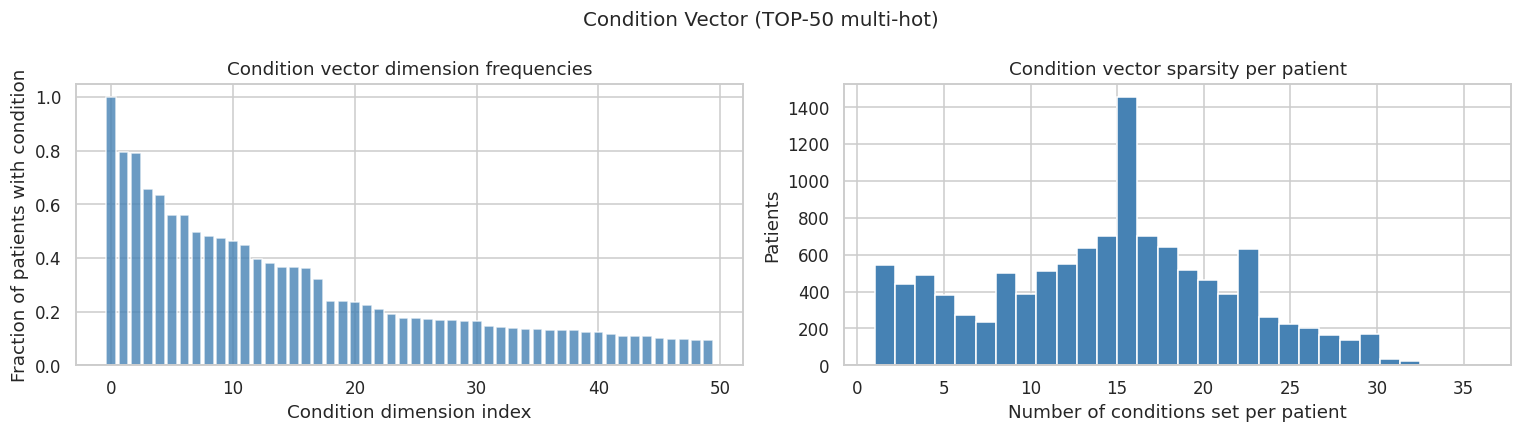

In [7]:
# Load condition vectors
df_vec = q("""
    SELECT patient_id, condition_vector
    FROM healthcare.patient_features
    ORDER BY patient_id
""")

# Convert list-of-lists to numpy matrix
vec_matrix = np.array(df_vec['condition_vector'].tolist(), dtype=np.float32)
print(f'Condition vector matrix shape: {vec_matrix.shape}')
print(f'Vector length (TOP_N):         {vec_matrix.shape[1]}')
print(f'Total non-zero entries:        {int(vec_matrix.sum()):,}')
print(f'Mean entries per patient:      {vec_matrix.sum(axis=1).mean():.1f}')
print(f'Max entries per patient:       {int(vec_matrix.sum(axis=1).max())}')

# Dimension frequency (how often each condition slot is set)
dim_freq = vec_matrix.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(dim_freq)), dim_freq, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Condition dimension index')
axes[0].set_ylabel('Fraction of patients with condition')
axes[0].set_title('Condition vector dimension frequencies')

axes[1].hist(vec_matrix.sum(axis=1), bins=30,
             color='steelblue', edgecolor='white')
axes[1].set_xlabel('Number of conditions set per patient')
axes[1].set_ylabel('Patients')
axes[1].set_title('Condition vector sparsity per patient')

plt.suptitle('Condition Vector (TOP-50 multi-hot)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Medication history flags (multi-hot)

Medication flags matrix shape: (11679, 50)
Total non-zero entries:        52,447
Mean flags per patient:        4.5


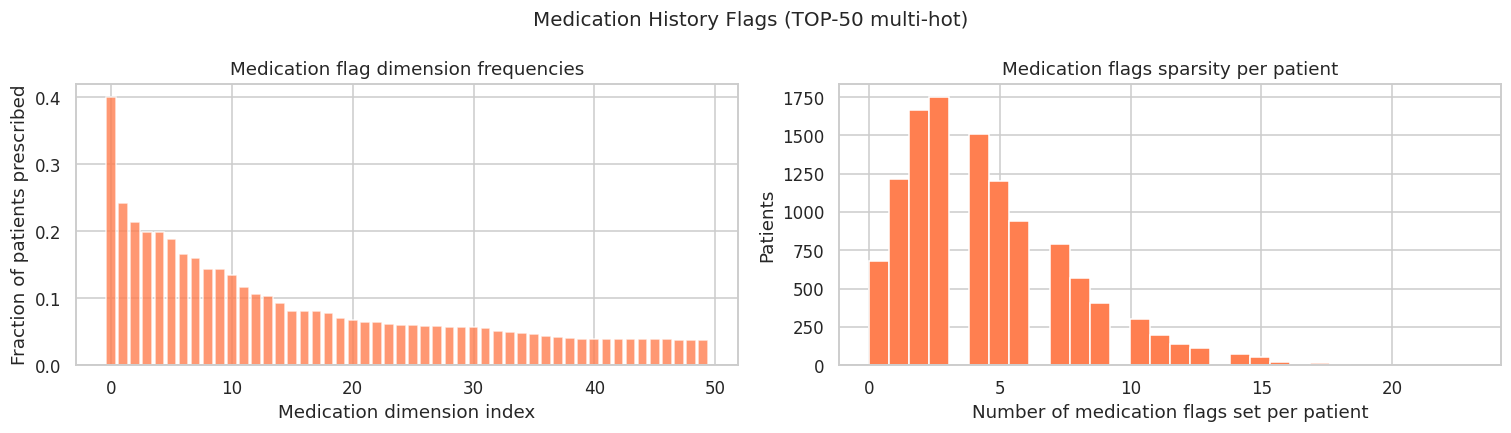

In [8]:
df_med = q("""
    SELECT patient_id, medication_history_flags
    FROM healthcare.patient_features
    ORDER BY patient_id
""")

med_matrix = np.array(df_med['medication_history_flags'].tolist(), dtype=np.float32)
print(f'Medication flags matrix shape: {med_matrix.shape}')
print(f'Total non-zero entries:        {int(med_matrix.sum()):,}')
print(f'Mean flags per patient:        {med_matrix.sum(axis=1).mean():.1f}')

med_freq = med_matrix.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(med_freq)), med_freq, color='coral', alpha=0.8)
axes[0].set_xlabel('Medication dimension index')
axes[0].set_ylabel('Fraction of patients prescribed')
axes[0].set_title('Medication flag dimension frequencies')

axes[1].hist(med_matrix.sum(axis=1), bins=30,
             color='coral', edgecolor='white')
axes[1].set_xlabel('Number of medication flags set per patient')
axes[1].set_ylabel('Patients')
axes[1].set_title('Medication flags sparsity per patient')

plt.suptitle('Medication History Flags (TOP-50 multi-hot)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Feature correlation matrix

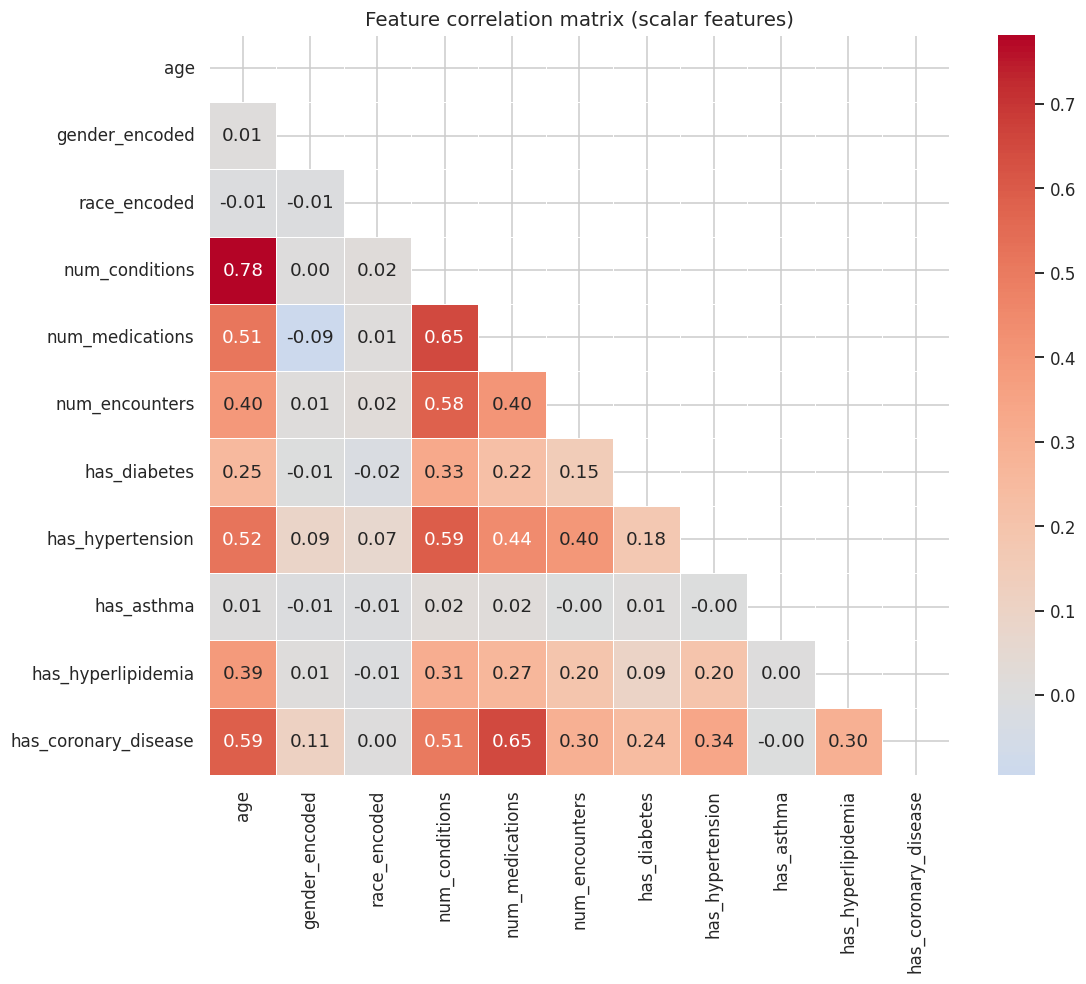

In [9]:
numeric_cols = [
    'age', 'gender_encoded', 'race_encoded',
    'num_conditions', 'num_medications', 'num_encounters',
    'has_diabetes', 'has_hypertension', 'has_asthma',
    'has_hyperlipidemia', 'has_coronary_disease',
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.4,
            mask=mask, square=True)
ax.set_title('Feature correlation matrix (scalar features)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Feature readiness summary

In [10]:
print('=' * 60)
print('FEATURE ENGINEERING SUMMARY')
print('=' * 60)
print(f'  Total patients:           {len(df):,}')
print(f'  Scalar features:          {len(numeric_cols)}')
print(f'  Condition vector dim:     {vec_matrix.shape[1]}')
print(f'  Medication flags dim:     {med_matrix.shape[1]}')
print(f'  Total feature dimensions: {len(numeric_cols) + vec_matrix.shape[1] + med_matrix.shape[1]}')
print()

# Null check
null_counts = df[numeric_cols].isnull().sum()
has_nulls = null_counts[null_counts > 0]
if len(has_nulls) == 0:
    print('  Null check:  PASS — no nulls in scalar features')
else:
    print(f'  Null check:  WARN — nulls found: {has_nulls.to_dict()}')

# Range checks
print(f'  Age range:   {df["age"].min()} – {df["age"].max()}')
print(f'  Gender:      {sorted(df["gender_encoded"].unique().tolist())} (0=F, 1=M)')
print(f'  Race:        {sorted(df["race_encoded"].unique().tolist())} (0-5)')
print()
print('  Ready for model training ✓')
print('=' * 60)

FEATURE ENGINEERING SUMMARY
  Total patients:           11,679
  Scalar features:          11
  Condition vector dim:     50
  Medication flags dim:     50
  Total feature dimensions: 111

  Null check:  PASS — no nulls in scalar features
  Age range:   0 – 110
  Gender:      [0, 1] (0=F, 1=M)
  Race:        [0, 1, 2, 3, 5] (0-5)

  Ready for model training ✓
